In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import io as sio
import seaborn as sns 
from sklearn.preprocessing import LabelBinarizer , StandardScaler ,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , accuracy_score,ConfusionMatrixDisplay
from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression , RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier 
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from numpy import absolute
from numpy import sqrt
from numpy import mean
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import pandas as pd
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier , GradientBoostingClassifier , VotingClassifier , RandomForestClassifier

In [3]:
data = pd.read_csv("Lung Cancer Dataset.csv")
data.head(10)

,GD,AG,SM,YF,AN,PP,CD,FT,AL,WH,AC,CF,SB,SD,CP,LC
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


In [4]:
data.tail()

,GD,AG,SM,YF,AN,PP,CD,FT,AL,WH,AC,CF,SB,SD,CP,LC
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES
308,M,62,1,1,1,2,1,2,2,2,2,1,1,2,1,YES


In [5]:
#Shape of Data
data.shape

(309, 16)

In [6]:
data['LC'].value_counts()

YES    270
NO      39
Name: LC, dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   GD      309 non-null    object
 1   AG      309 non-null    int64 
 2   SM      309 non-null    int64 
 3   YF      309 non-null    int64 
 4   AN      309 non-null    int64 
 5   PP      309 non-null    int64 
 6   CD      309 non-null    int64 
 7   FT      309 non-null    int64 
 8   AL      309 non-null    int64 
 9   WH      309 non-null    int64 
 10  AC      309 non-null    int64 
 11  CF      309 non-null    int64 
 12  SB      309 non-null    int64 
 13  SD      309 non-null    int64 
 14  CP      309 non-null    int64 
 15  LC      309 non-null    object
dtypes: int64(14), object(2)
memory usage: 38.8+ KB


In [8]:
#lets describe the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
AG,309.0,62.673139,8.210301,21.0,57.0,62.0,69.0,87.0
SM,309.0,1.563107,0.496806,1.0,1.0,2.0,2.0,2.0
YF,309.0,1.569579,0.495938,1.0,1.0,2.0,2.0,2.0
AN,309.0,1.498382,0.500808,1.0,1.0,1.0,2.0,2.0
PP,309.0,1.501618,0.500808,1.0,1.0,2.0,2.0,2.0
CD,309.0,1.504854,0.500787,1.0,1.0,2.0,2.0,2.0
FT,309.0,1.673139,0.469827,1.0,1.0,2.0,2.0,2.0
AL,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
WH,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
AC,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0


In [9]:
data.count()

GD    309
AG    309
SM    309
YF    309
AN    309
PP    309
CD    309
FT    309
AL    309
WH    309
AC    309
CF    309
SB    309
SD    309
CP    309
LC    309
dtype: int64

In [10]:
label_encoder = preprocessing.LabelEncoder()
data['GD']= label_encoder.fit_transform(data['GD'])
  
data['GD'].unique()

array([1, 0])

In [11]:
label_encoder = preprocessing.LabelEncoder()
data['LC']= label_encoder.fit_transform(data['LC'])
  
data['LC'].unique()

array([1, 0])

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
GD,309.0,0.524272,0.500221,0.0,0.0,1.0,1.0,1.0
AG,309.0,62.673139,8.210301,21.0,57.0,62.0,69.0,87.0
SM,309.0,1.563107,0.496806,1.0,1.0,2.0,2.0,2.0
YF,309.0,1.569579,0.495938,1.0,1.0,2.0,2.0,2.0
AN,309.0,1.498382,0.500808,1.0,1.0,1.0,2.0,2.0
PP,309.0,1.501618,0.500808,1.0,1.0,2.0,2.0,2.0
CD,309.0,1.504854,0.500787,1.0,1.0,2.0,2.0,2.0
FT,309.0,1.673139,0.469827,1.0,1.0,2.0,2.0,2.0
AL,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
WH,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0


In [13]:
#sns.pairplot(data)

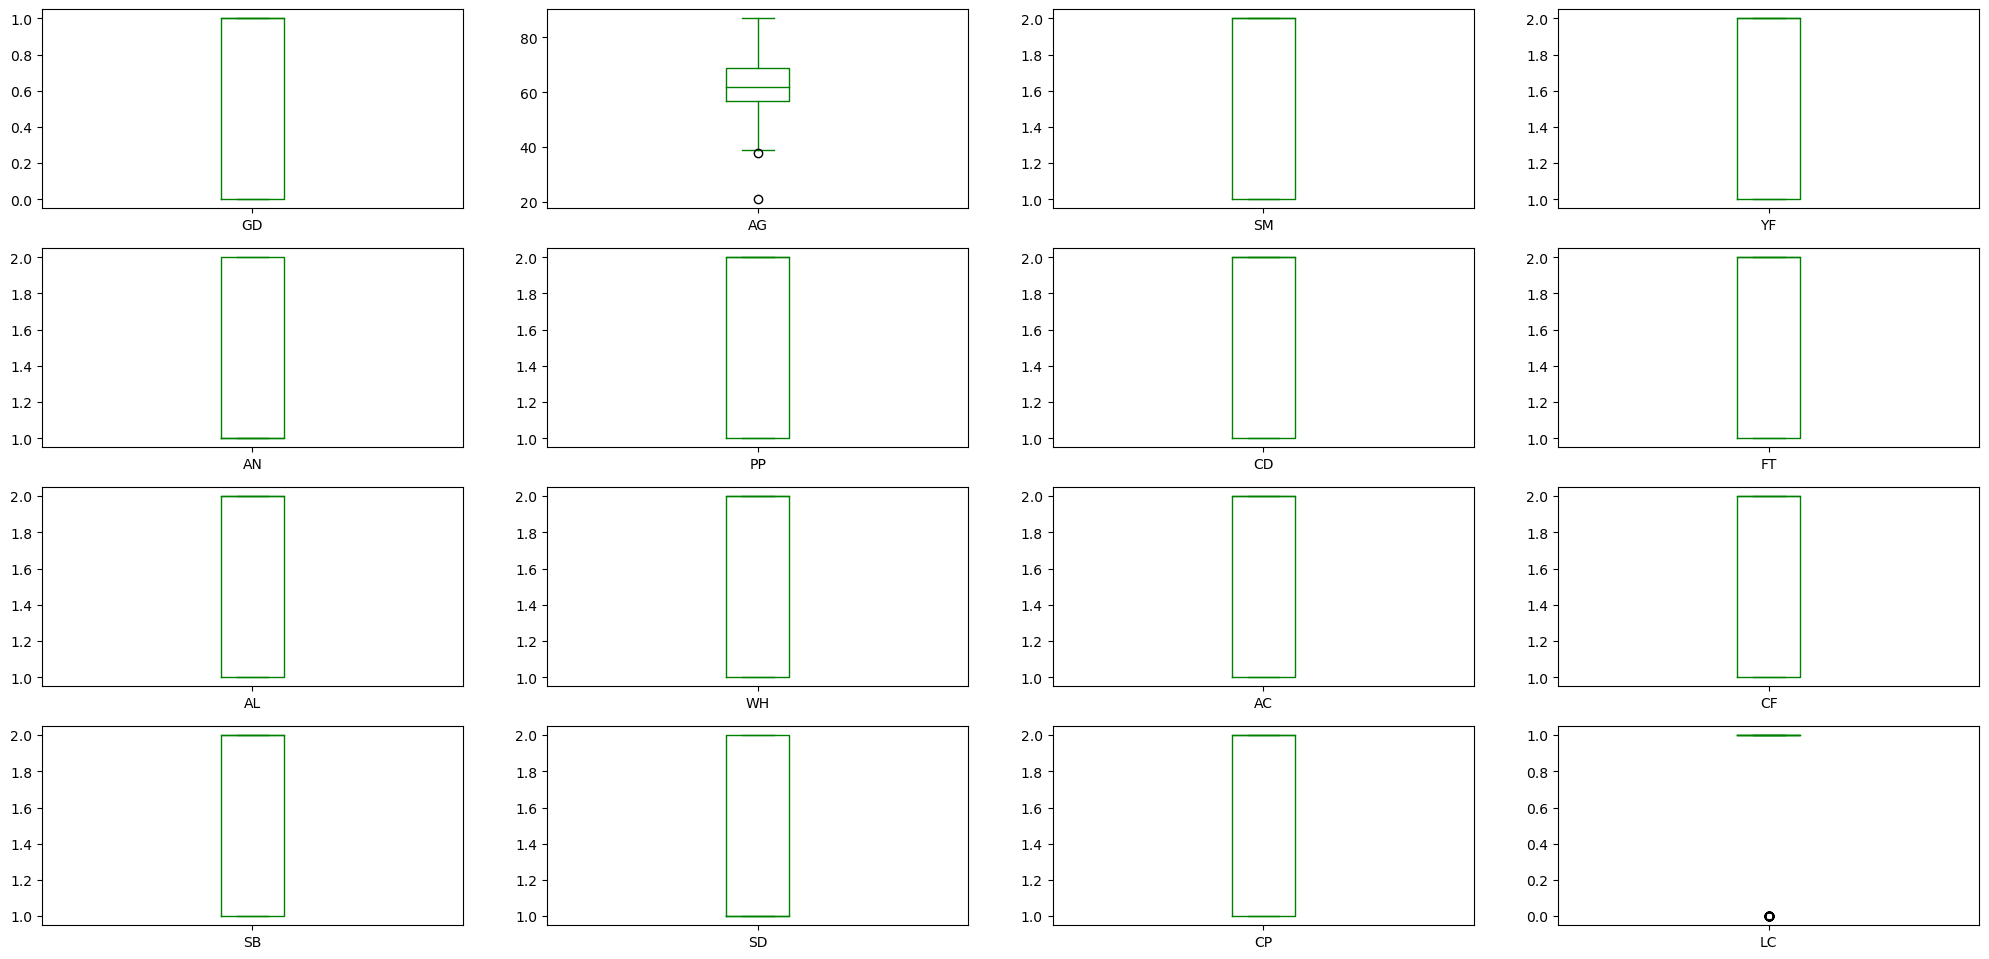

In [14]:
data.plot(color = 'green', kind='box', figsize=(25, 15), subplots=True, layout=(5,4))
plt.show()

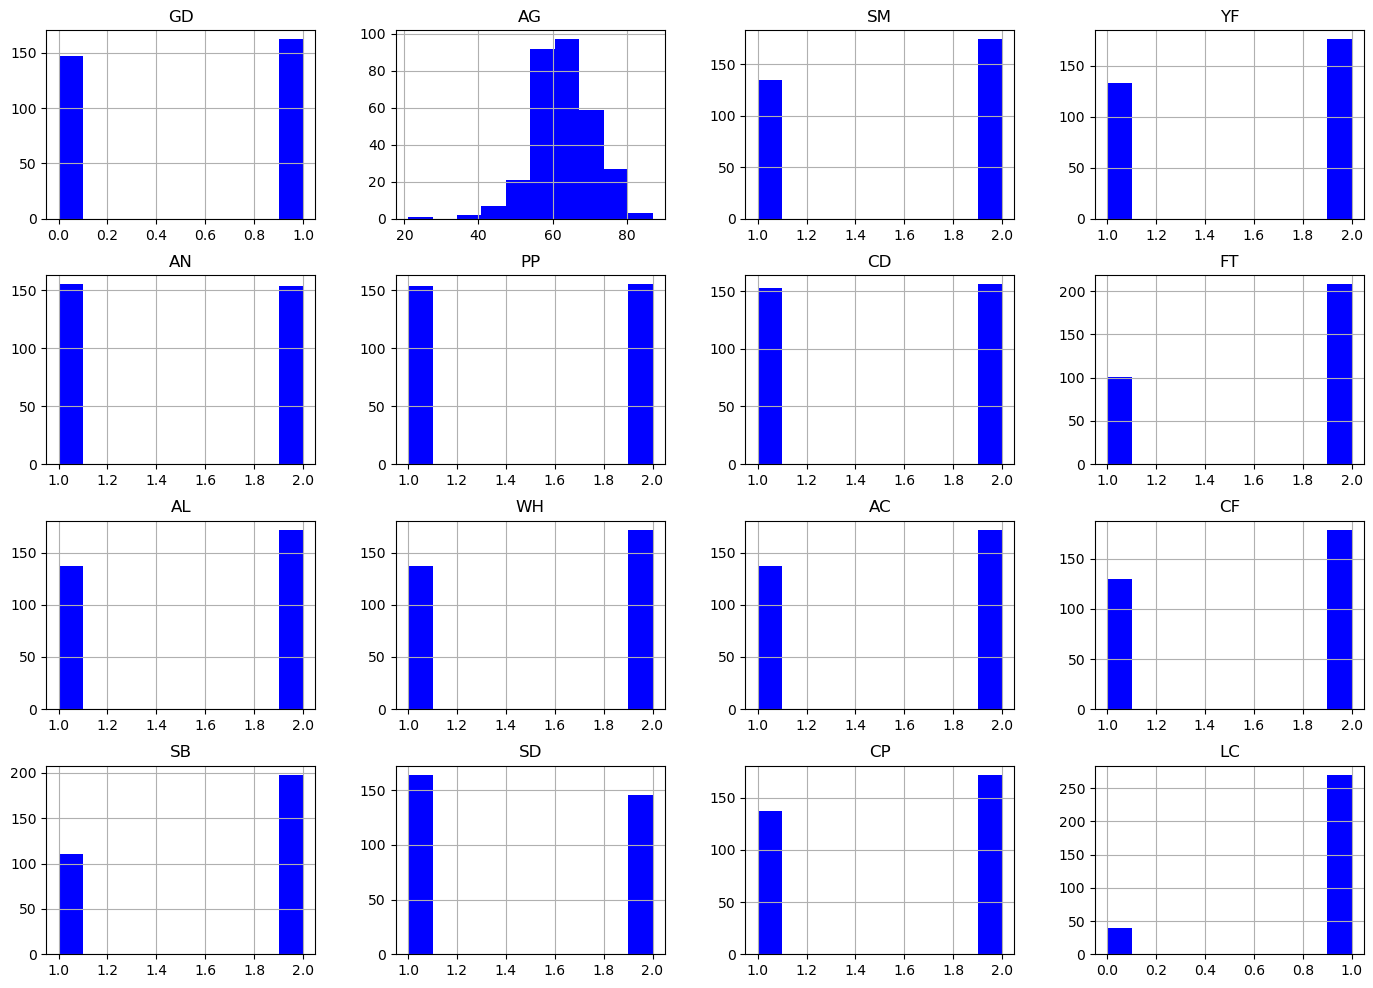

In [15]:
#histogram
data.hist(color='blue',bins=10,figsize=(17,12))
plt.show()

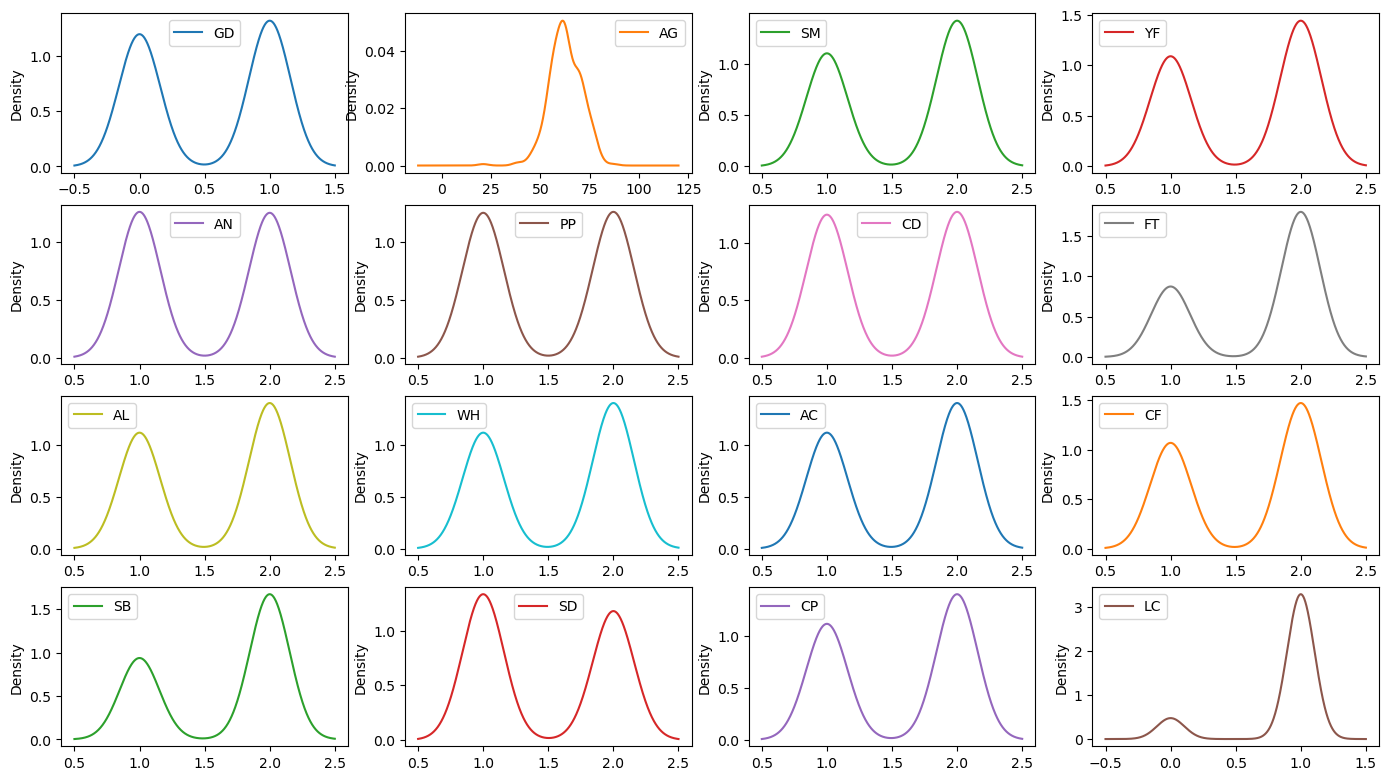

In [16]:
#Boxplot of each column
data.plot( kind='density', figsize=(17,12), subplots=True, layout=(5,4),sharex=False)

plt.show()


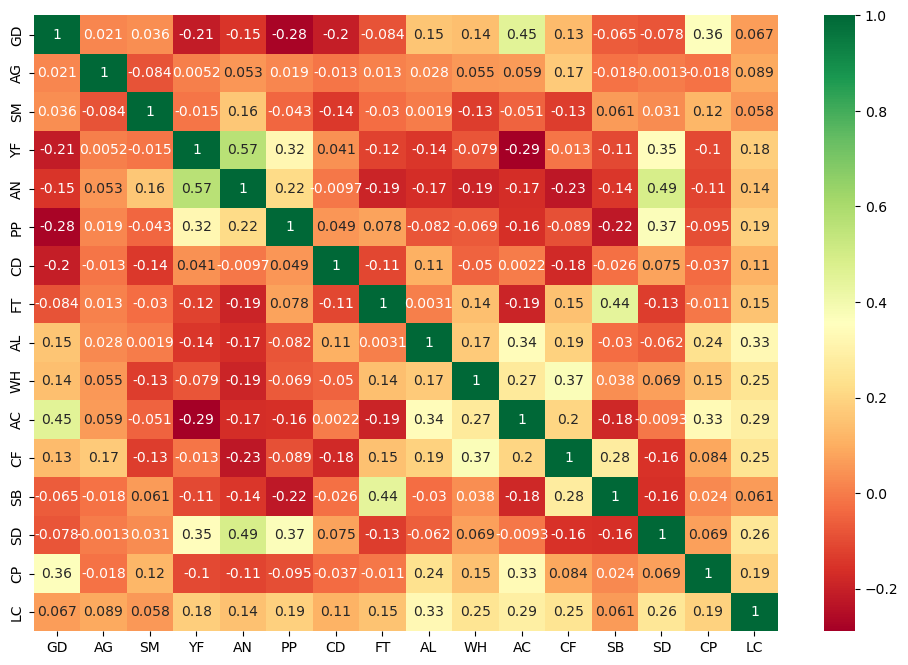

In [17]:
#get correlations of each features in dataset
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(12,8))
#plot heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [18]:
#checking for the out layers with STD
print("Highest allowed",data['AG'].mean() + 3*data['AG'].std())
print("Lowest allowed",data['AG'].mean() - 3*data['AG'].std())

Highest allowed 87.30404332223404
Lowest allowed 38.04223499491807


In [19]:
#dealing with out layer values 
data[(data['AG'] > 87) | (data['AG'] < 45)]


,GD,AG,SM,YF,AN,PP,CD,FT,AL,WH,AC,CF,SB,SD,CP,LC
20,0,44,2,2,2,2,2,2,1,1,1,1,2,2,1,1
22,0,21,2,1,1,1,2,2,2,1,1,1,2,1,1,0
168,1,44,1,2,1,2,2,2,1,2,1,1,2,2,2,1
238,0,38,1,2,1,1,2,2,2,2,1,2,2,1,2,1
261,1,39,2,1,1,2,1,2,2,2,2,1,2,1,2,1


In [20]:
new_df = data[(data['AG'] <87) & (data['AG'] >45)]
new_df

,GD,AG,SM,YF,AN,PP,CD,FT,AL,WH,AC,CF,SB,SD,CP,LC
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,0,56,1,1,1,2,2,2,1,1,2,2,2,2,1,1
305,1,70,2,1,1,1,1,2,2,2,2,2,2,1,2,1
306,1,58,2,1,1,1,1,1,2,2,2,2,1,1,2,1
307,1,67,2,1,2,1,1,2,2,1,2,2,2,1,2,1


In [21]:
#storing the values 
upper_limit = data['AG'].mean() + 3*data['AG'].std()
lower_limit = data['AG'].mean() - 3*data['AG'].std()

In [22]:
data['AG'] = np.where(
    data['AG']>upper_limit,
    upper_limit,
    np.where(
        data['AG']<lower_limit,
        lower_limit,
        data['AG']
    )
)

C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_3804\733725874.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['AG'])
C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_3804\733725874.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['AG'])


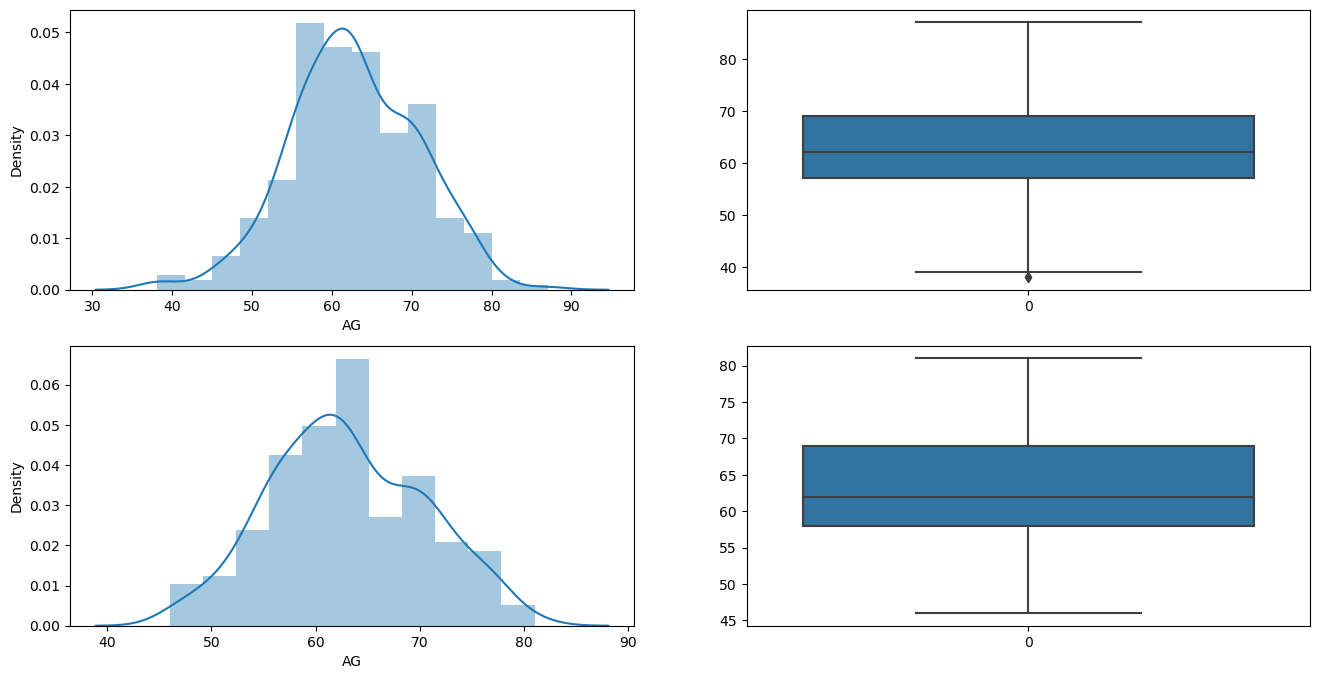

In [23]:
#ploting the outlayer removing 
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['AG'])
plt.subplot(2,2,2)
sns.boxplot(data['AG'])
plt.subplot(2,2,3)
sns.distplot(new_df['AG'])
plt.subplot(2,2,4)
sns.boxplot(new_df['AG'])
plt.show()

<Axes: >

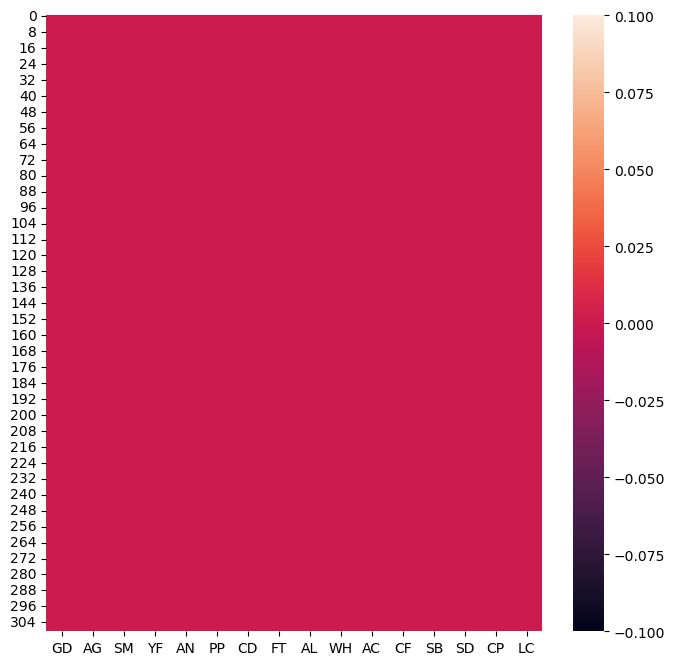

In [24]:
plt.figure(figsize=(8,8))
sns.heatmap(data.isnull())

In [25]:
data_boxcox = data.copy()
X = data_boxcox.drop(['LC'],axis=1)
Y = data_boxcox['LC']

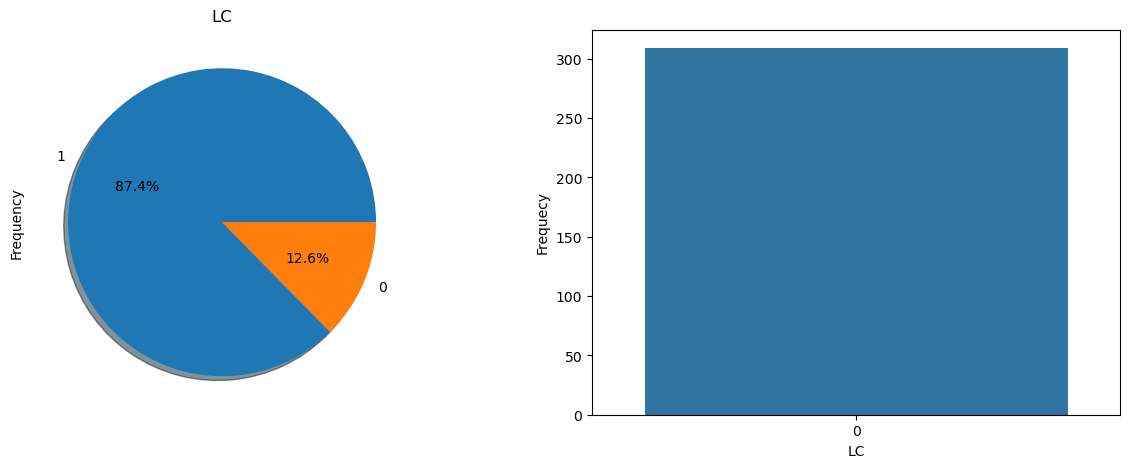

In [26]:
#Plot the diabetic Values
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(data['LC'])
#plt.title("Frequency of Heart Disease in Dataset")
plt.xlabel("LC")
plt.ylabel("Frequecy")

#Piechart show
data['LC'].value_counts().plot.pie(explode=None,autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('LC')
ax[0].set_ylabel('Frequency')
plt.show()

In [27]:

#To keep BoxCox data as it is to use the same for later.
data_bal = data_boxcox.copy()

#Getting seperated data with 1 and 0 status.
df_majority = data_bal[data_bal.LC==1]
df_minority = data_bal[data_bal.LC==0]

#Here we are downsampling the Majority Class Data Points. 
#i.e. We will get equal amount of datapoint as Minority class from Majority class
df_manjority_downsampled = resample(df_majority,replace=False,n_samples=150,random_state=123)
df_downsampled = pd.concat([df_manjority_downsampled,df_minority])
print("Downsampled data:->\n",df_downsampled.LC.value_counts())

#Here we are upsampling the Minority Class Data Points. 
#i.e. We will get equal amount of datapoint as Majority class from Minority class
df_minority_Upsampled = resample(df_minority,replace=True,n_samples=350,random_state=123)
df_Upsampled = pd.concat([df_majority,df_minority_Upsampled])
print("Upsampled data:->\n",df_Upsampled.LC.value_counts())

Downsampled data:->
 1    150
0     39
Name: LC, dtype: int64
Upsampled data:->
 0    350
1    270
Name: LC, dtype: int64


Text(0.5, 0, 'Outcome')

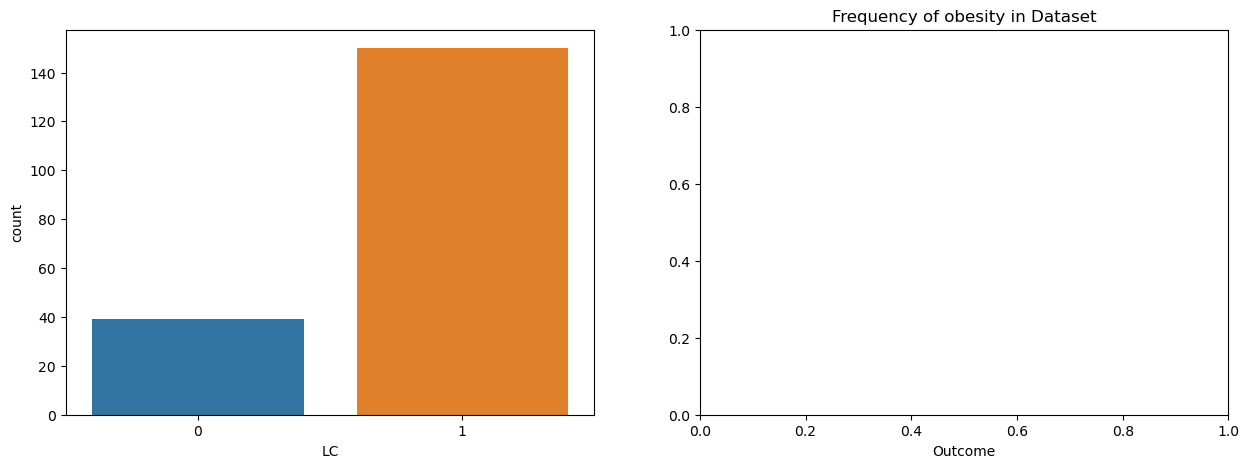

In [28]:
#Plot the diabetic Values
# f,ax=plt.subplots(1,2,figsize=(15,5))
# sns.countplot(df_downsampled['NObeyesdad'])
# plt.title("Frequency of Heart Disease in Dataset")
# plt.xlabel("NObeyesdad")
# plt.ylabel("Frequecy")
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='LC', data=df_downsampled, ax=ax[0])
plt.title("Frequency of obesity in Dataset")
plt.xlabel("Outcome")

#Piechart show
# df_downsampled['NObeyesdad'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
# ax[0].set_title('NObeyesdad')
# ax[0].set_ylabel('Frequency')
# plt.show()

Text(0.5, 0, 'Outcome')

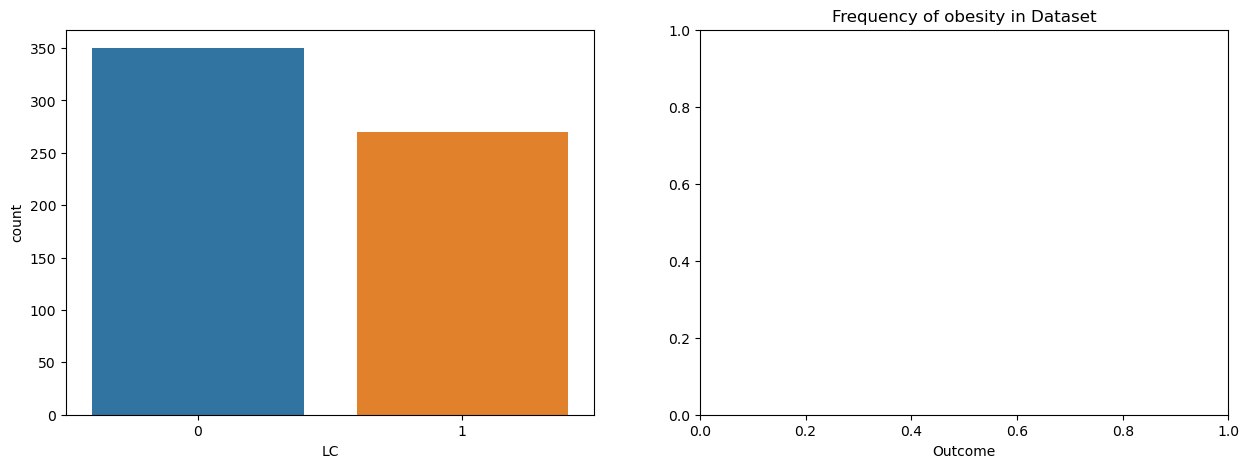

In [29]:
# #Plot the diabetic Values
# f,ax=plt.subplots(1,2,figsize=(15,5))
# sns.countplot(df_Upsampled['NObeyesdad'])
# plt.title("Frequency of Heart Disease in Dataset")
# plt.xlabel('NObeyesdad')
# plt.ylabel("Frequecy")
# #Piechart show
# df_Upsampled['NObeyesdad'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
# ax[0].set_title('NObeyesdad')
# ax[0].set_ylabel('Frequency')
# plt.show()
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='LC', data=df_Upsampled, ax=ax[0])
plt.title("Frequency of obesity in Dataset")
plt.xlabel("Outcome")

In [30]:
#lets describe the data
df_Upsampled.describe().T

,count,mean,std,min,25%,50%,75%,max
GD,620.0,0.467742,0.499361,0.000000,0.0,0.0,1.0,1.0
AG,620.0,61.954043,7.926498,38.042235,58.0,62.0,67.0,87.0
SM,620.0,1.525806,0.499737,1.000000,1.0,2.0,2.0,2.0
YF,620.0,1.453226,0.498209,1.000000,1.0,1.0,2.0,2.0
AN,620.0,1.403226,0.490941,1.000000,1.0,1.0,2.0,2.0
PP,620.0,1.383871,0.486720,1.000000,1.0,1.0,2.0,2.0
CD,620.0,1.448387,0.497731,1.000000,1.0,1.0,2.0,2.0
FT,620.0,1.566129,0.496008,1.000000,1.0,2.0,2.0,2.0
AL,620.0,1.346774,0.476327,1.000000,1.0,1.0,2.0,2.0
WH,620.0,1.382258,0.486331,1.000000,1.0,1.0,2.0,2.0


In [31]:
#lets describe the data
df_downsampled.describe().T

,count,mean,std,min,25%,50%,75%,max
GD,189.0,0.486772,0.501153,0.000000,0.0,0.0,1.0,1.0
AG,189.0,62.635368,8.151377,38.042235,57.0,63.0,69.0,87.0
SM,189.0,1.571429,0.496186,1.000000,1.0,2.0,2.0,2.0
YF,189.0,1.560847,0.497602,1.000000,1.0,2.0,2.0,2.0
AN,189.0,1.476190,0.500759,1.000000,1.0,1.0,2.0,2.0
PP,189.0,1.497354,0.501321,1.000000,1.0,1.0,2.0,2.0
CD,189.0,1.518519,0.500984,1.000000,1.0,2.0,2.0,2.0
FT,189.0,1.629630,0.484186,1.000000,1.0,2.0,2.0,2.0
AL,189.0,1.534392,0.500141,1.000000,1.0,2.0,2.0,2.0
WH,189.0,1.523810,0.500759,1.000000,1.0,2.0,2.0,2.0


In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
import itertools
import xgboost as xgb
from sklearn import  metrics 

In [37]:
data.columns

Index(['GD', 'AG', 'SM', 'YF', 'AN', 'PP', 'CD', 'FT', 'AL', 'WH', 'AC', 'CF',
       'SB', 'SD', 'CP', 'LC'],
      dtype='object')

In [38]:
X = np.array(df_Upsampled[['GD', 'AG', 'SM', 'YF', 'AN', 'PP', 'CD', 'FT', 'AL', 'WH', 'AC', 'CF',
       'SB', 'SD', 'CP', 'LC']])
Y = np.array(df_Upsampled.LC.T)
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.20,random_state=0)


models = []
models.append(("XGB",XGBClassifier()))
models.append(("ADB",AdaBoostClassifier()))
models.append(("GB",GradientBoostingClassifier()))
models.append(("LightGBM",LGBMClassifier()))
models.append(("Catboost",CatBoostClassifier()))

## GB Boost

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        69
           1       0.96      0.96      0.96        55

    accuracy                           0.97       124
   macro avg       0.97      0.97      0.97       124
weighted avg       0.97      0.97      0.97       124

0.967741935483871


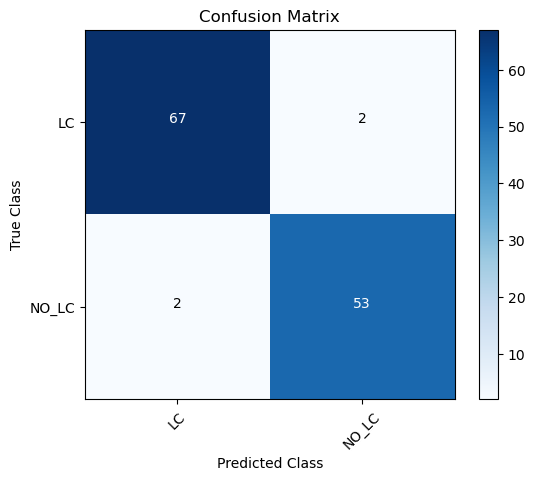

In [40]:
classes = ["LC", "NO_LC"]
X = df_Upsampled.drop(['LC'],axis=1)
Y = df_Upsampled['LC']
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.20,random_state=0)
Model3 = GradientBoostingClassifier(random_state=45, learning_rate =0.1,n_estimators=10000,max_depth=10)
Model3.fit(X_train,y_train)
y_pred = Model3.predict(X_test)
fpr_Model3, tpr_Model3, thresholds_Model3 = roc_curve(y_test, y_pred)
roc_auc_Model3 = auc (fpr_Model3, tpr_Model3)
precision_Model3, recall_Model3, th_Model3 = precision_recall_curve(y_test, y_pred)
print(classification_report(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
#plot_confusion_matrix(Model3,X_test,y_test,display_labels=["LD","Non-LD"],cmap=plt.cm.Blues)
# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add labels to the plot
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")


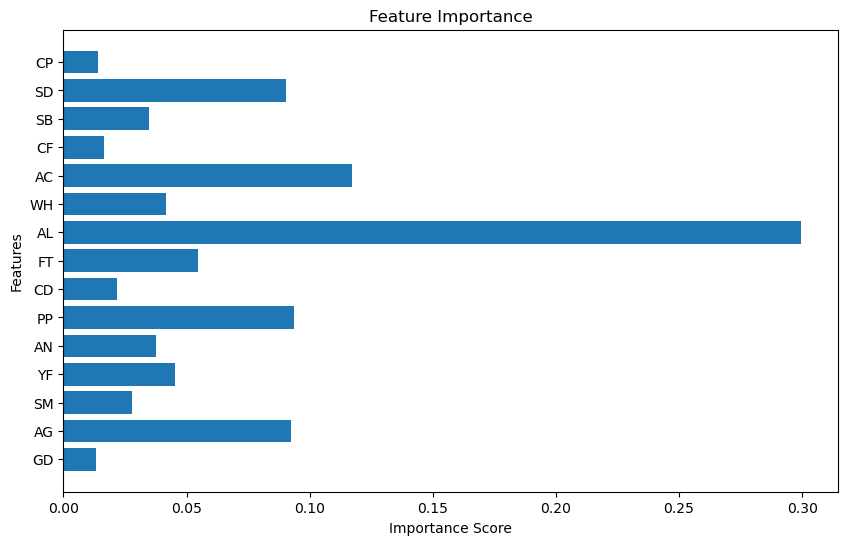

In [41]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

# Get the feature importance scores
importance_scores = gbr.feature_importances_
feature_names = X_train.columns

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance_scores)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

## XAI

In [46]:
import shap
shap.initjs()

### SHAP

In [47]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(Model3.predict, X_train)
shap_values = explainer(X_test)

PermutationExplainer explainer: 125it [00:28,  4.42it/s]                                                               


In [48]:
np.shape(shap_values.values)

(124, 15)

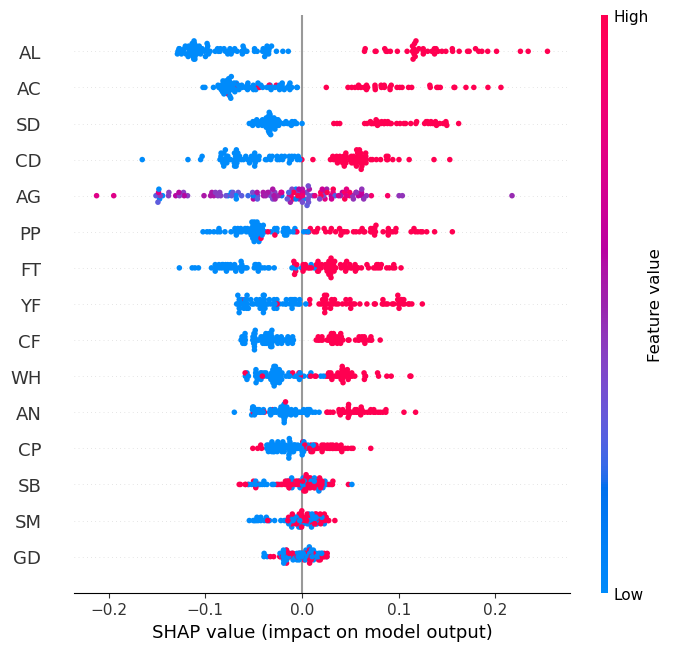

In [58]:
shap.plots.beeswarm(shap_values, max_display=len(shap_values.feature_names))

In [62]:
shap.plots.force(shap_values[100])

In [63]:
shap.plots.force(shap_values[0:100])

### LIME

In [65]:
#!pip install lime

import lime
import lime.lime_tabular

In [66]:
# Create a LimeTabularExplainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X.values,  # Use the NumPy array representation of X
    feature_names=X.columns.tolist(), # Feature names for interpretability
    class_names=['LC','NO_LC'], # Class names
    mode='classification' # or 'regression' depending on the task
)

In [69]:
# Choose an instance to explain
instance_index = 100 # Example: explain the instance
instance = X.iloc[instance_index]

In [71]:
# Explain the instance
explanation = explainer.explain_instance(
    instance.values,
    lambda x: Model5.predict_proba(pd.DataFrame(x, columns=X.columns)), # Use a lambda function to wrap the prediction
    num_features=15  # Number of features to show in explanation
)

In [72]:
# Show the explanation
explanation.show_in_notebook(show_table=True)

In [74]:
explanation.as_list()

[('1.00 < AL <= 2.00', 0.2726507168166528),
 ('AC <= 1.00', -0.230029807848848),
 ('CD <= 1.00', -0.16892295723590645),
 ('1.00 < SD <= 2.00', 0.1421681675259264),
 ('1.00 < FT <= 2.00', 0.12479141704452879),
 ('1.00 < PP <= 2.00', 0.11186418494234138),
 ('1.00 < YF <= 2.00', 0.1042767354263031),
 ('1.00 < AN <= 2.00', 0.09629035378651313),
 ('CF <= 1.00', -0.09486655552209301),
 ('WH <= 1.00', -0.08427007736285669),
 ('AG <= 58.00', -0.06618765404668651),
 ('CP <= 1.00', -0.05487704061574692),
 ('1.00 < SB <= 2.00', 0.022997186766443006),
 ('1.00 < SM <= 2.00', 0.012113189916768992),
 ('GD <= 0.00', 0.006210593007992766)]